In [629]:
#%pip install pandas matplotlib plotly seaborn numpy

In [630]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import plotly.express as px
import seaborn as sns
import numpy as np

# Importazione dei dati


In [631]:
path="clean_datasets"

In [632]:
# Load datasets
try:
    df_actors = pd.read_csv(os.path.join(path, "df_actors.csv"))
    df_countries = pd.read_csv(os.path.join(path, "df_countries.csv"))
    df_crew = pd.read_csv(os.path.join(path, "df_crew.csv"))
    df_released_movies = pd.read_csv(os.path.join(path, "df_released_movies.csv"))
    df_unreleased_movies = pd.read_csv(os.path.join(path, "df_unreleased_movies.csv"))
    df_movies = pd.read_csv(os.path.join(path, "df_movies.csv"))
    df_languages = pd.read_csv(os.path.join(path, "df_languages.csv"))
    df_posters = pd.read_csv(os.path.join(path, "df_posters.csv"))
    df_releases = pd.read_csv(os.path.join(path, "df_releases.csv"))
    df_themes = pd.read_csv(os.path.join(path, "df_themes.csv"))
    df_genres = pd.read_csv(os.path.join(path, "df_genres.csv"))
    df_studios = pd.read_csv(os.path.join(path, "df_studios.csv"))
    df_tomatoes= pd.read_csv(os.path.join(path, "df_tomatoes.csv"))
    df_oscars = pd.read_csv(os.path.join(path, "df_oscars.csv"))
except Exception as e:
    print(e)

[Errno 2] No such file or directory: 'clean_datasets/df_actors.csv'


# **Analisi dei Dati**


## Evoluzione e influenze: la storia dei rating cinematografici nel tempo

- Come è cambiato il rating del pubblico dei film nel tempo?
- Come è cambiato il rating della critica dei film nel tempo?
- Quali sono state le cause di questo cambiamento?
- La percezione della qualità dei film, e quindi delle valutazioni, è influenzata anche da altri fattori? Proviamo a trovare correlazioni con il genere e con la durata


Per partire con la nostra analisi, visualiziamo l'andamento di film usciti per anno


In [633]:
df_released_movies

,id,name,date,tagline,description,minute,rating,name_norm
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86,barbie
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56,parasite
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30,everything everywhere all at once
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27,fight club
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09,la la land
...,...,...,...,...,...,...,...,...
826012,1940967,A Nursery In Paris,1909.0,NaN,Short film showing a nursery.,2.0,NaN,a nursery in paris
826013,1940968,I klädloge och på scen,1908.0,NaN,Miss Inga Berentz dresses up for the entrance....,7.0,NaN,i klädloge och på scen
826014,1940969,Danse fantaisiste,1902.0,NaN,"""Danse fantaisiste"" (Gaumont #589) is part of ...",NaN,NaN,danse fantaisiste
826015,1940970,La Gigue,1902.0,NaN,"""La Gigue"" (Gaumont #590) is part of the ""Miss...",NaN,NaN,la gigue


In [634]:
films_per_year = df_released_movies.copy() #analizziamo solo i film rilasciati
films_per_year = films_per_year[(films_per_year['date'] >= 1830) & (films_per_year['date'] <= 2020)] #prendiamo solo i film dal 1830 al 2020 perchè è il range contenente più informazioni
films_per_year = films_per_year.groupby("date").size() 

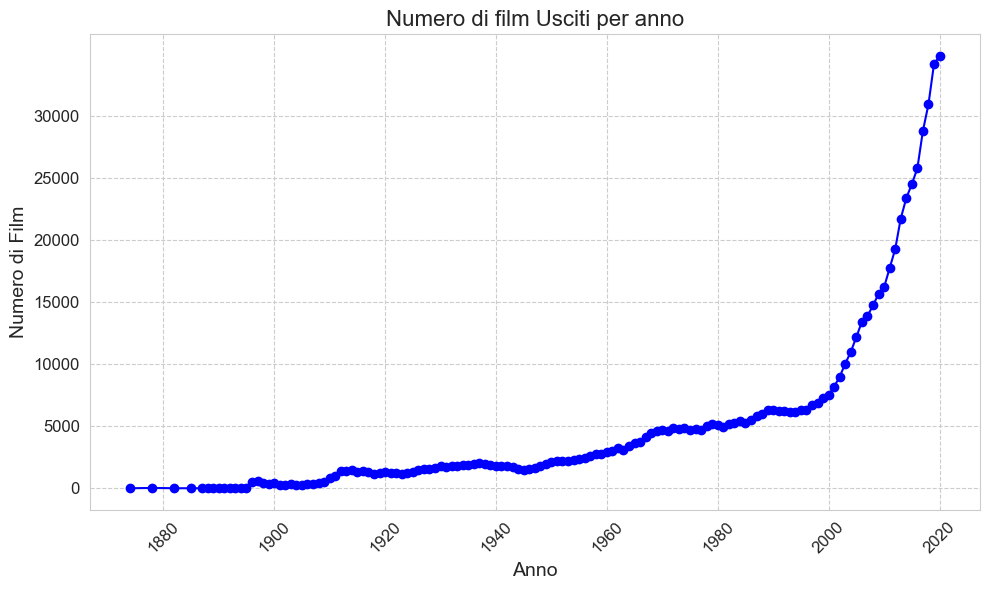

In [635]:
plt.figure(figsize=(10, 6))
plt.plot(films_per_year.index, films_per_year.values, marker='o', linestyle='-', color='blue', label="Numero di Film")
plt.title("Numero di film Usciti per anno", fontsize=16)
plt.xlabel("Anno", fontsize=14)
plt.ylabel("Numero di Film", fontsize=14)
plt.xticks(fontsize=12, rotation=45)
max_y = films_per_year.max()
yticks = list(range(0, max_y + 10, 5000))  
plt.yticks(yticks, fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Vi è stato un chiaro incremento nel tempo nel numero di film prodotti per anno, fino ad un improvviso crollo di pubblicazioni, che possiamo attribuire probabilmente alla nascita e all'evoluzione del COVID degli anni recenti.

Ora possiamo analizzare come invece si è evoluta in media la valutazione dei film nei diversi anni da parte del pubblico.


In [636]:
rating_trend = df_released_movies.groupby('date')['rating'].mean().reset_index()
rating_trend = rating_trend[(rating_trend['date'] >= 1830) & (rating_trend['date'] <= 2020)]

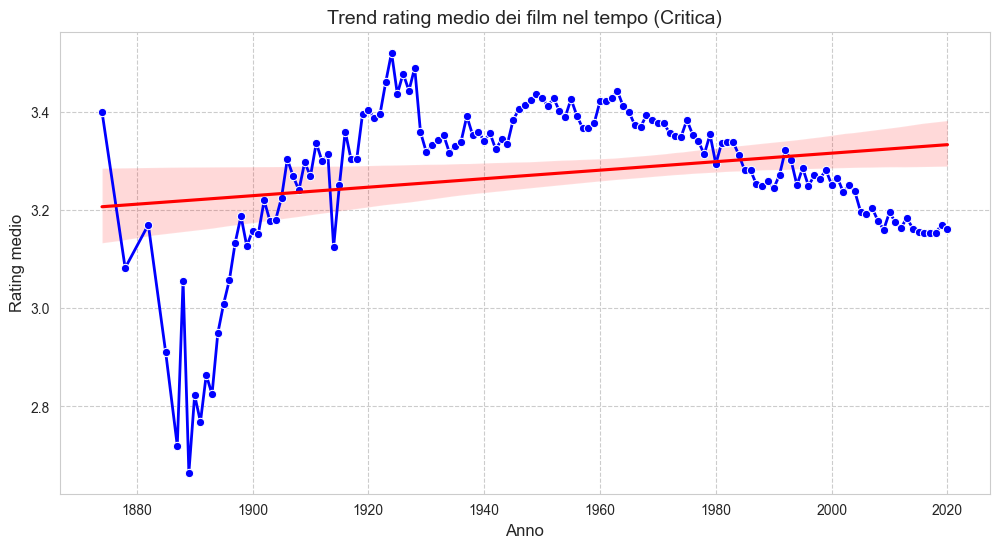

In [637]:
plt.figure(figsize=(12,6))
sns.lineplot(data=rating_trend, x='date', y='rating', marker='o', linewidth=2, color='b')
sns.regplot(x=rating_trend['date'], y=rating_trend['rating'], scatter=False, color="red", label="Trend")
plt.title("Trend rating medio dei film nel tempo (Critica)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True, linestyle='--')
plt.show()

Negli inizi degli anni tra il 1920 e il 1940 abbiamo un picco di rating medio, mentre da quel punto possiamo notare un lento calo nelle valutazioni effettuate.

In corrispondenza possiamo visualizzare l'andamento della critica.


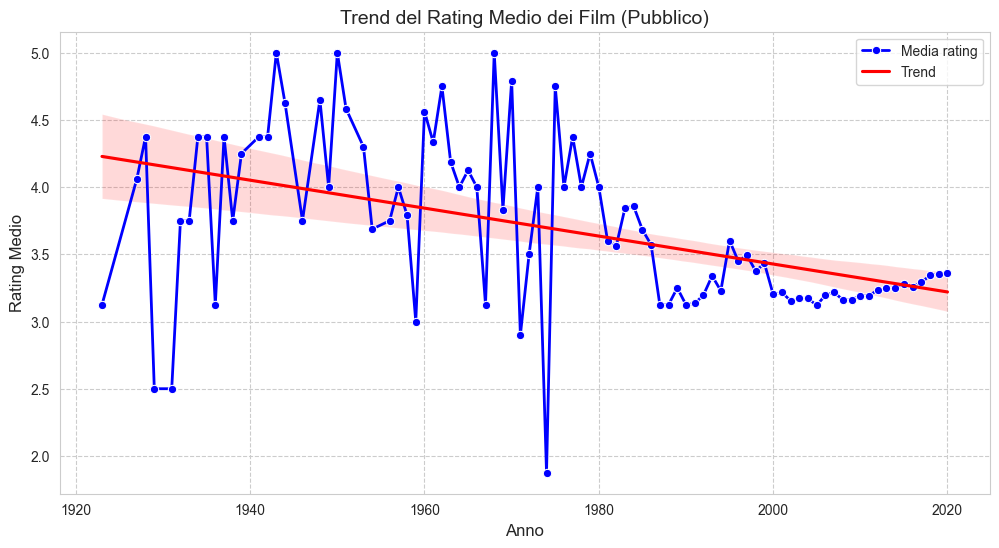

In [638]:
rating_trend = df_tomatoes.copy() #recensioni utenti rotten tomatoes

rating_trend['year'] = pd.to_datetime(rating_trend['review_date'], errors='coerce').dt.year
rating_trend = rating_trend[(rating_trend['year'] >= 1830) & (rating_trend['year'] <= 2025)] #filtriamo per evitare dati sporchi
rating_trend = rating_trend.groupby('year')['rating'].mean().reset_index() #raggruppiamo per anno e calcoliamo la media del rating
#plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=rating_trend['year'], y=rating_trend['rating'], marker="o",linewidth=2, color='b', label="Media rating")
sns.regplot(x=rating_trend['year'], y=rating_trend['rating'], scatter=False, color="red", label="Trend")
plt.title("Trend del Rating Medio dei Film (Pubblico)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating Medio", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

Possiamo notare come anche i rating dei critici siano stato in calo durante il tempo, fino ad una quasi stabilizzazione negli anni più recenti, questo però nota come i valori da parte dei critici siano diversi rispetto a quello del pubblico.
Quindi anche se in comune vi è il tranding verso il basso, i critici annualmente,in media, hanno assegnato generalmente valori più alti come rating verso i film in uscita.
Perciò possiamo intuire che sia il pubblico che ha sviluppato una qualità per cui la popolarità dei film sia diminuita nel tempo.


In [639]:
rating_public = df_tomatoes.copy()
rating_public['year'] = pd.to_datetime(rating_public['review_date'], errors='coerce').dt.year
rating_public = rating_public[(rating_public['year'] >= 1920) & (rating_public['year'] <= 2025)]

rating_critics = df_released_movies.copy()
rating_critics = rating_critics.rename(columns={'rating': 'critics_rating', 'date': 'year'})

bins = list(range(1920, 2025, 5))  # fino al 2020, bucket di 5 anni
rating_public['year_bin'] = pd.cut(rating_public['year'], bins=bins, right=False) #creiamo i bin per il raggruppamento
rating_critics['year_bin'] = pd.cut(rating_critics['year'], bins=bins, right=False)

public_avg = rating_public.groupby('year_bin',observed=True)['rating'].mean().reset_index() #raggruppiamo per bucket e calcoliamo la media del rating all'interno del bucket
public_avg.rename(columns={'rating': 'public_rating'}, inplace=True) #sempplice rename

critics_avg = rating_critics.groupby('year_bin',observed=True)['critics_rating'].mean().reset_index()

In [640]:
merged_rating = pd.merge(public_avg, critics_avg, on='year_bin', how='inner')
merged_rating['year_str'] = merged_rating['year_bin'].astype(str) #converto in stringa per il plot


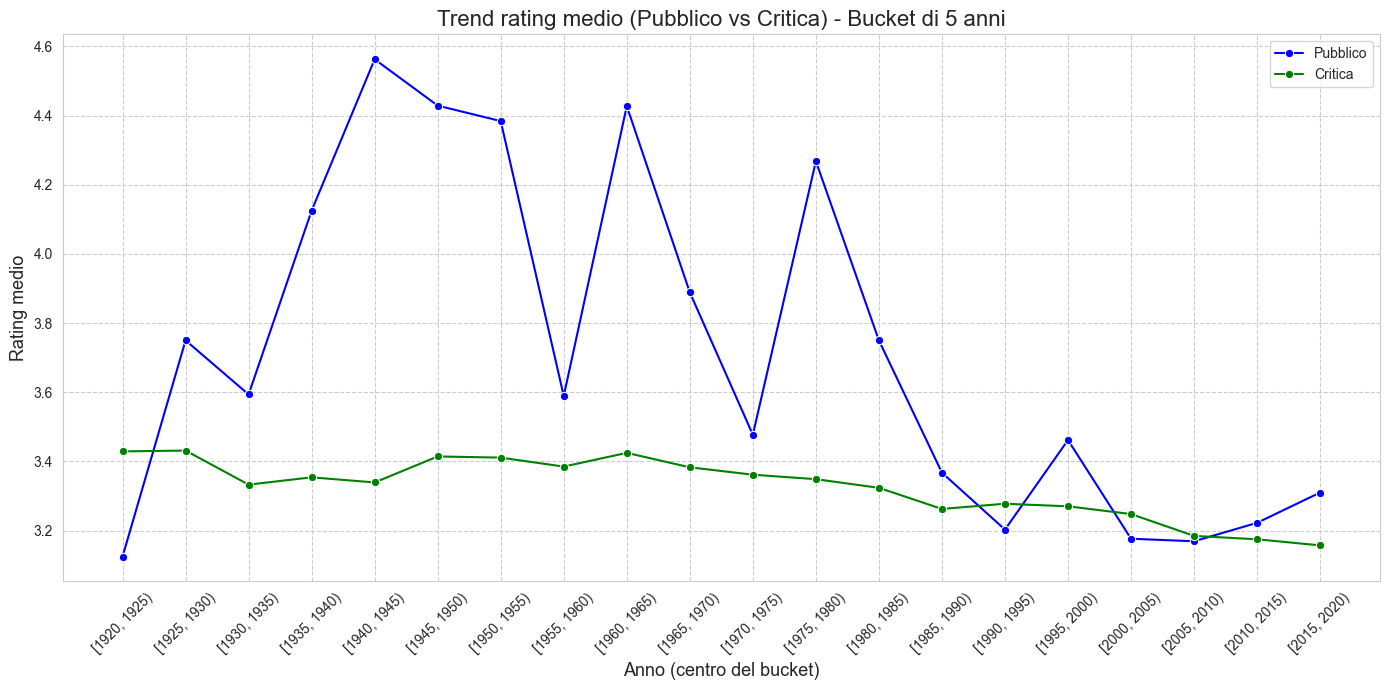

In [641]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='year_str', y='public_rating', data=merged_rating, marker='o', color='blue', label='Pubblico')
sns.lineplot(x='year_str', y='critics_rating', data=merged_rating, marker='o', color='green', label='Critica')

plt.title("Trend rating medio (Pubblico vs Critica) - Bucket di 5 anni", fontsize=16)
plt.xlabel("Anno (centro del bucket)", fontsize=13)
plt.ylabel("Rating medio", fontsize=13)
plt.legend()
plt.grid(True, linestyle='--')
plt.xticks(rotation=45)  #inclino per leggibilità
plt.tight_layout()
plt.show()

Se il rating medio della critica dal 1920 fino ad oggi è pressochè stabile con un lieve calo dal 1960 in poi, possiamo notare come invece il rating del pubblico varia spesso di anno in anno, probabilmente perchè i gusti cambiano gli eventi storici influenzano drasticamente le valutazioni.


In [642]:
public = df_tomatoes.copy()
public['year'] = pd.to_datetime(public['review_date'], errors='coerce').dt.year
public = public.dropna(subset=['year']) #per sicurezza
public['year'] = public['year'].astype(int) #per sicurezza
public = public[(public['year'] >= 1920) & (public['year'] <= 2020)] #filtriamo per evitare dati sporchi
public_counts = public.groupby('year').size().reset_index(name='count') #contiamo occerrenze
public_counts['source'] = 'Pubblico'

In [643]:
critics = df_released_movies.copy()
critics = critics.dropna(subset=['date'])
critics['year'] = critics['date'].astype(int)
critics = critics[(critics['year'] >= 1920) & (critics['year'] <= 2020)] #filtriamo per evitare dati sporchi
critics_counts = critics.groupby('year').size().reset_index(name='count') #contiamo occerrenze
critics_counts['source'] = 'Critica'

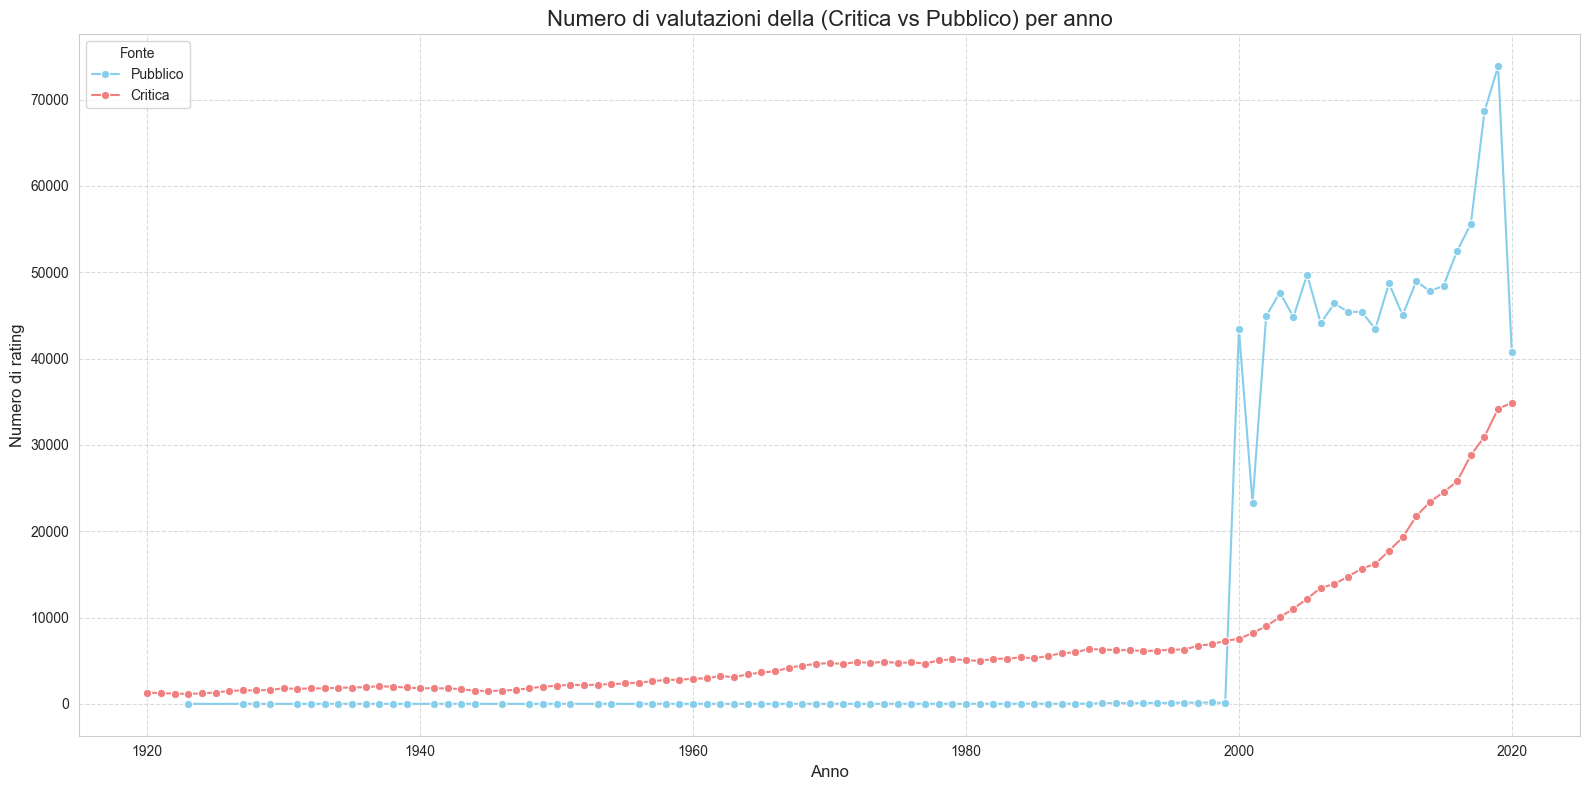

In [644]:
df_counts = pd.concat([public_counts, critics_counts], ignore_index=True)

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_counts, x='year', y='count', hue='source', marker='o', palette={'Pubblico': 'skyblue', 'Critica': 'lightcoral'})
plt.title("Numero di valutazioni della (Critica vs Pubblico) per anno", fontsize=16)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Numero di rating", fontsize=12)
plt.legend(title="Fonte")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Abbiamo dedotto quindi che nel nostro dataset non sono presenti un significativo numero di valutazioni del pubblico prima del 2000. La parte interessante quindi è dal 2000 in poi, e come possiamo vedere dal grafico precedente le linee del rating medio tra critica e pubblico si stabilizza pressochè sullo stesso valore.

Possiamo dedurre che i gusti del pubblico e dei critici si allineano, negli ultimi anni.


## Proviamo a scoprire, nonostante le poche valutazioni per il giudizio del pubblico, alcuni fattori di correlazione tra il rating e il genere

Esiste un genere che sbilancia in positivo o in negativo il rating medio per periodo?


In [645]:
df_unique_released_movies = df_released_movies.copy().drop_duplicates(subset=['name', 'date']) #elimino i duplicati

In [646]:
movies_genres = pd.merge(df_unique_released_movies, df_genres, left_on="id", right_on="id_film", how="inner")
movies_genres = movies_genres.sort_values(by=['id', 'genre']).drop_duplicates(subset=['id'], keep='first')

rating_medio = df_tomatoes.groupby('movie_title')['rating'].mean().reset_index() # raggruppiamo per titolo e calcoliamo la media del rating
df_tomatoes_copy = df_tomatoes.copy().drop(columns=['rating']).drop_duplicates(subset=['movie_title'], keep='first') #eliminiamo i duplicati
df_unificato = pd.merge(df_tomatoes_copy, rating_medio, on='movie_title', how='inner')

moviessss = pd.merge(movies_genres, df_unificato, left_on="name", right_on="movie_title", how="inner")

top_genres = moviessss["genre"].value_counts().nlargest(10).index
filtered_movies = moviessss[moviessss["genre"].isin(top_genres)]

df_meltato = filtered_movies.melt(
    id_vars=['genre'],
    value_vars=['rating_x', 'rating_y'],  # rating_x = critica, rating_y = pubblico
    var_name='Rating_Type',
    value_name='Rating'
)


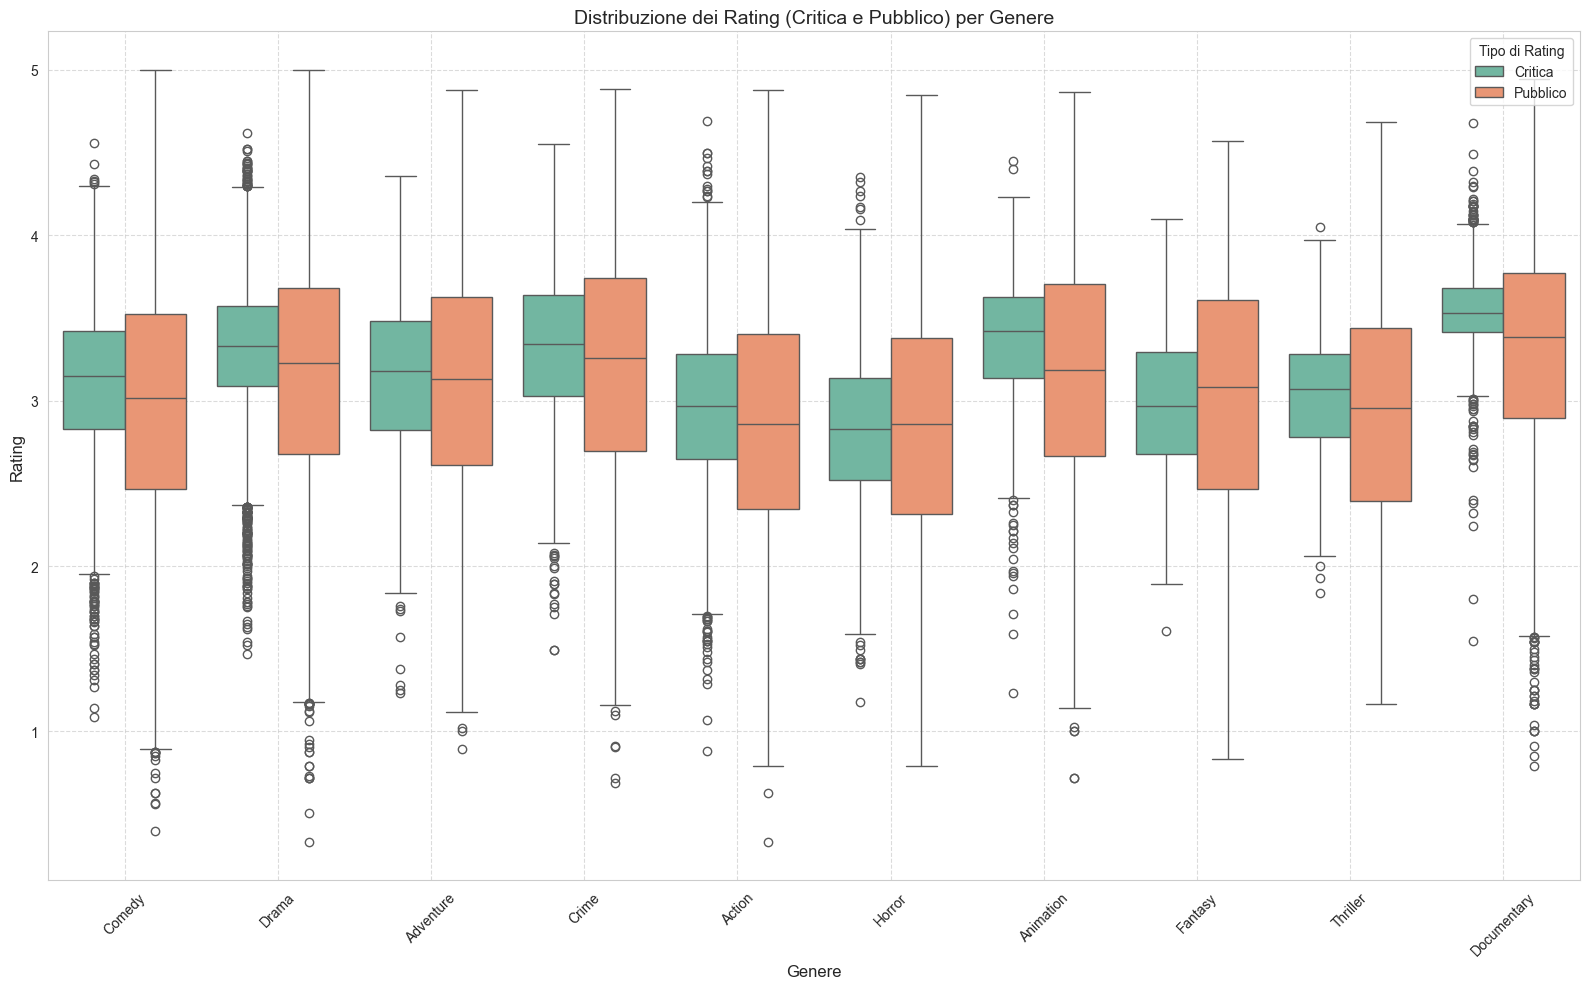

In [647]:
custom_palette = {
    'rating_x': '#66c2a5',  # verde acqua per la critica
    'rating_y': '#fc8d62',  # arancione per il pubblico
    }
plt.figure(figsize=(16, 10))
ax = sns.boxplot(
    data=df_meltato,
    x="genre",
    y="Rating",
    hue="Rating_Type",
    palette=custom_palette
)
handles, labels = ax.get_legend_handles_labels()
plt.title("Distribuzione dei Rating (Critica e Pubblico) per Genere", fontsize=14)
plt.xlabel("Genere", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(
    handles=handles,
    labels=["Critica", "Pubblico"],
    title="Tipo di Rating",
    loc='upper right'
)
plt.tight_layout()
plt.show()

Tornando al primo grafico sul numero di film pubblicati nel tempo,potremmo pensare che la causa di questo calo di valutazioni sia data dal continuo aumento nel numero di film che vengono prodotti.
Un numero ingente di film ogni anno porterebbe ad una possibile ripetitività nei film che di conseguenza annoierebbe lo spettatore medio.


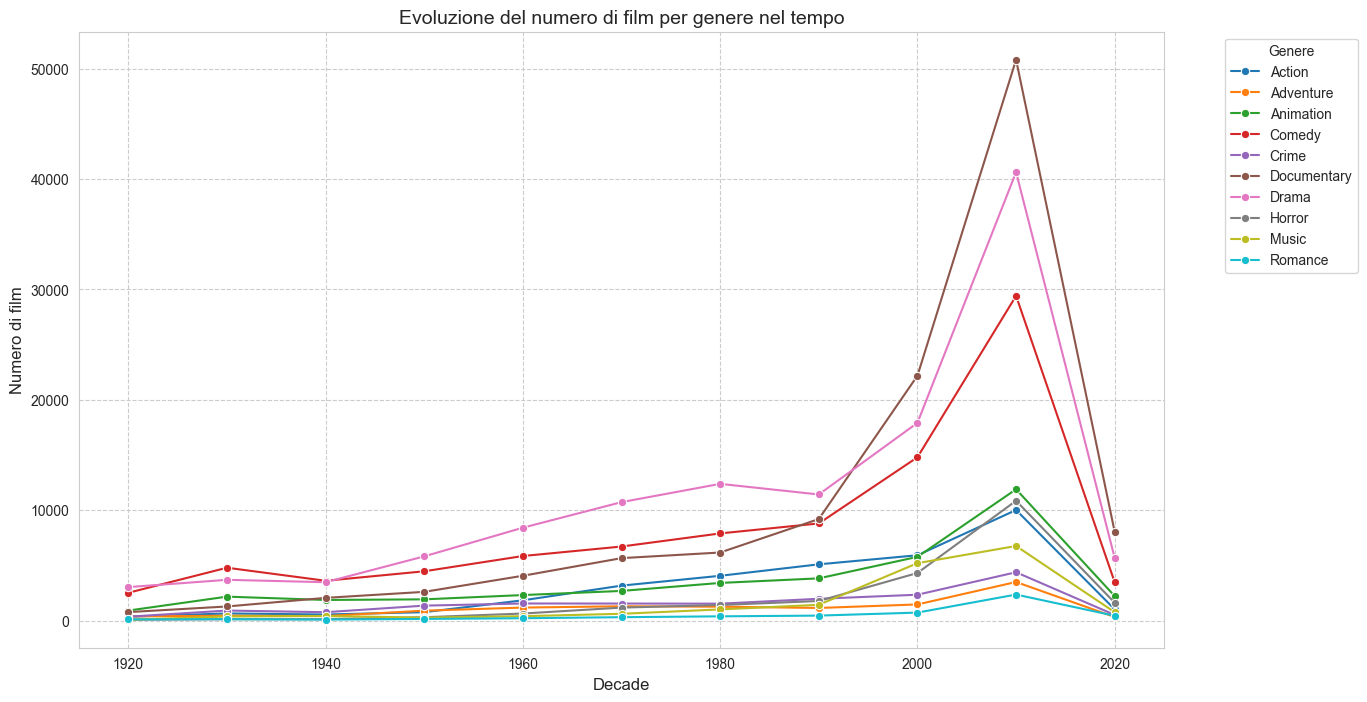

In [648]:
movies_genres_filt=movies_genres[(movies_genres['date'] > 1920) & (movies_genres['date'] <= 2020)].copy() # filtriamo per evitare dati sporchi
movies_genres_filt['decade'] = (movies_genres_filt['date'] // 10) * 10
genre_trend = movies_genres_filt.groupby(['decade', 'genre']).size().reset_index(name='film_count') # raggruppiamo per decennio e genere e contiamo il numero di film

top_genres = movies_genres_filt["genre"].value_counts().nlargest(10).index # prendiamo i 10 generi più popolari
filtered_trend = genre_trend[genre_trend['genre'].isin(top_genres)] # filtriamo per i generi più popolari

plt.figure(figsize=(14, 8))
sns.lineplot(data=filtered_trend, x="decade", y="film_count", hue="genre", marker="o")
plt.title("Evoluzione del numero di film per genere nel tempo", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Numero di film", fontsize=12)
plt.legend(title="Genere", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.show()

Vi è una crescita sostanziale tra il numero di film pubblicati, possiamo verificare se vi è una dipendenza con il rating per chiederci se producendo un numero maggiore di film la loro qualità diminuisca.


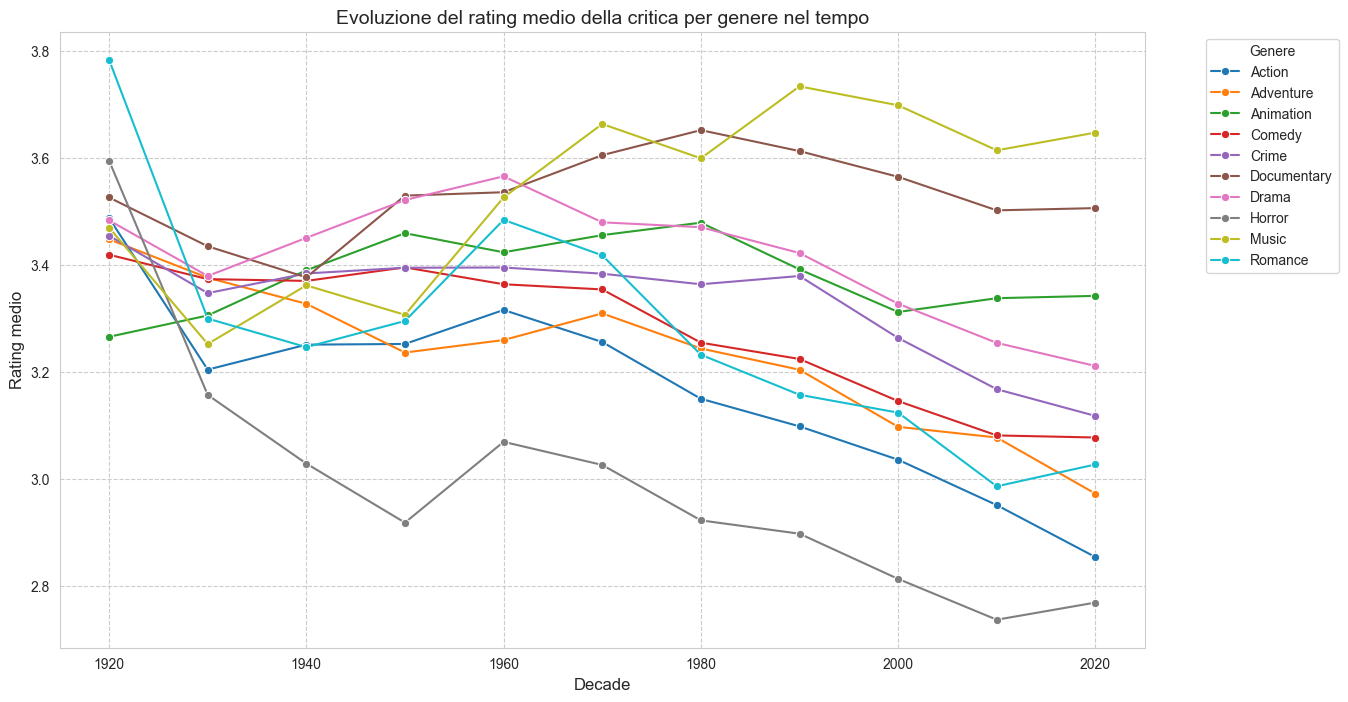

In [649]:
genre_rating_trend = movies_genres_filt.groupby(['decade', 'genre'])['rating'].mean().reset_index(name='average_rating') # calcoliamo la media del rating per ogni decennio e genere

# filtriamo per gli stessi generi
filtered_rating_trend = genre_rating_trend[genre_rating_trend['genre'].isin(top_genres)] # prendiamo solo i generi più popolari


plt.figure(figsize=(14, 8))
sns.lineplot(data=filtered_rating_trend, x="decade", y="average_rating", hue="genre", marker="o")
plt.title("Evoluzione del rating medio della critica per genere nel tempo", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.legend(title="Genere", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.show()

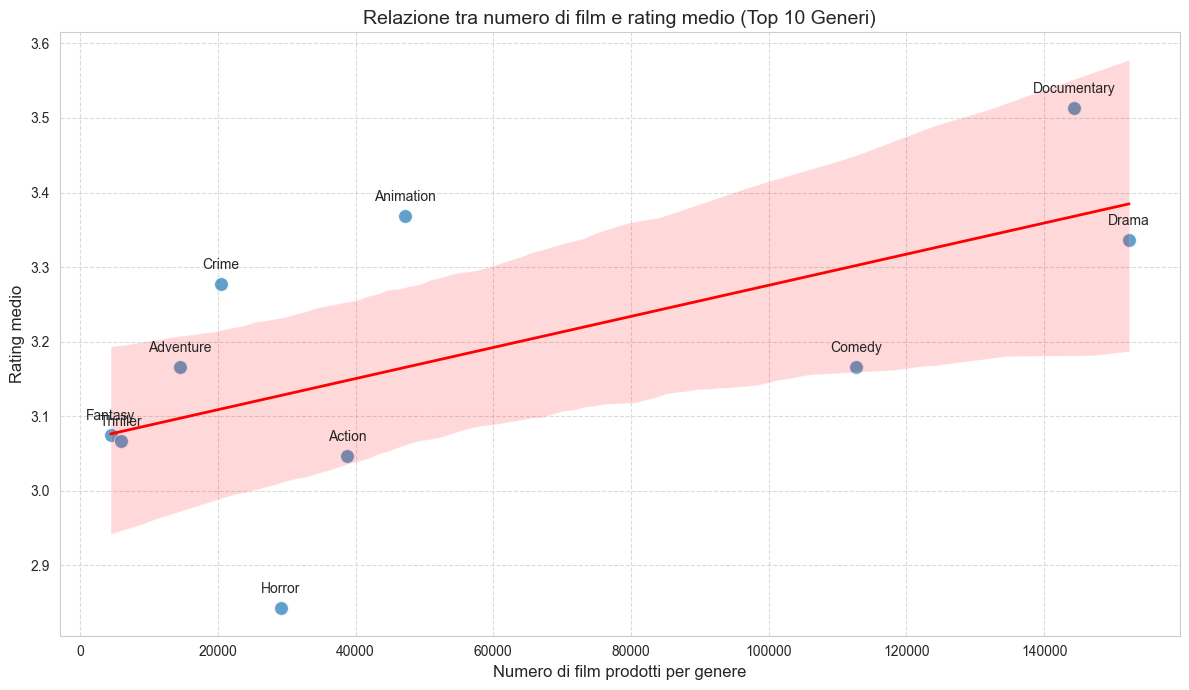

In [650]:
top_genres = moviessss["genre"].value_counts().nlargest(10).index

genre_stats_top = movies_genres[movies_genres["genre"].isin(top_genres)].groupby("genre").agg(
    film_count=("id_film", "count"),
    avg_rating=("rating", "mean")
).reset_index() # raggruppiamo per genere e calcoliamo il numero di film e la media del rating

plt.figure(figsize=(12, 7))

sns.scatterplot(data=genre_stats_top, x="film_count", y="avg_rating", alpha=0.7, s=100) # scatter plot

sns.regplot(data=genre_stats_top, x="film_count", y="avg_rating", scatter=False, color="red", line_kws={"linewidth": 2}) # linea di regressione

plt.title("Relazione tra numero di film e rating medio (Top 10 Generi)", fontsize=14)
plt.xlabel("Numero di film prodotti per genere", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

for i, row in genre_stats_top.iterrows():
    plt.text(row["film_count"], row["avg_rating"] + 0.02, row["genre"], fontsize=10, ha='center')

plt.tight_layout()
plt.show()


Per rispondere alla nostra domanda precedente, notiamo che in realtà la correlazione è leggermente positiva (linea rossa in crescita), quindi anche se il numero di film di genere aumenta, la maggior parte dei rating medi tende a salire.
Per esempio il Drama è il genere più prolifico, perchè con un vasto numero di film prodotti mantiene un rating medio del 3.3 .
Notiamo che i Documentari hanno il rating medio più alto mentre gli Horror quello minore.
Quindi non vediamo un chiaro calo del rating, generi molto prodotti riescono a mantenere abbastanza un buon rating medio, mentre quelli meno prodotti hanno rating più alti ma con molta variabilità.


Resta però che anche se in piccola quantità, la quantità di film prodotti per genere impatta il voto medio, probabilmente a causa di una minore attenzione alla qualità dei film stessi.


Possiamo pensare però che sia la durata dei film stessi a incidere sul loro rating, quindi film più lunghi possono avere valutazioni peggiori o migliori.


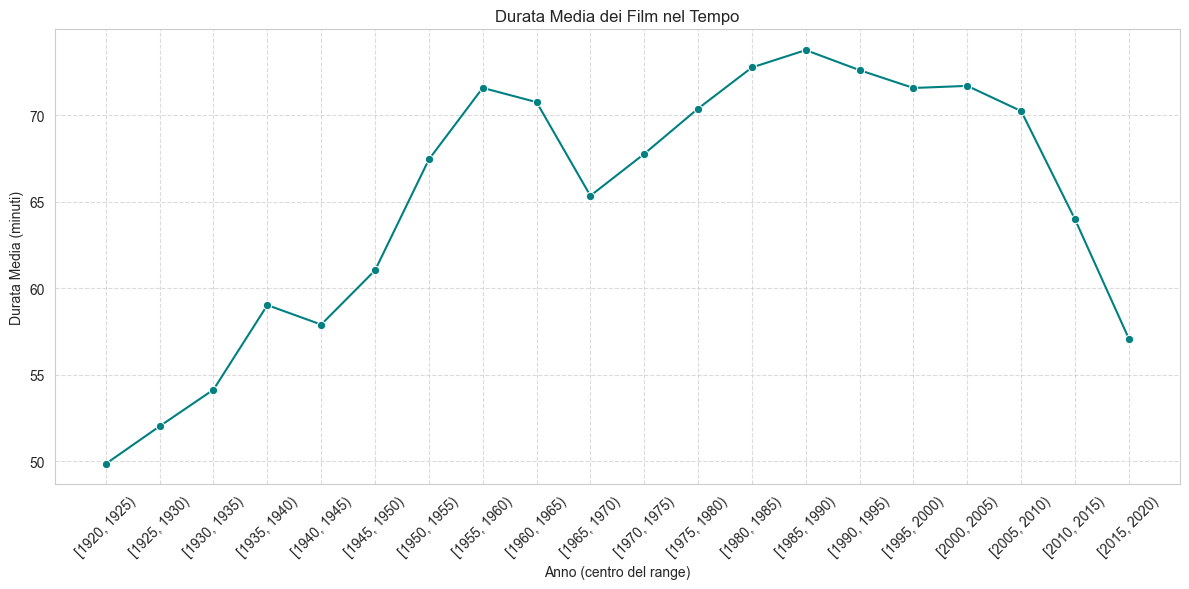

In [651]:
durata_media_anni = df_released_movies.copy()
durata_media_anni['year_bin'] = pd.cut(durata_media_anni['date'], bins=bins, right=False) # creiamo i bin per il raggruppamento

durata_media_aggregata = durata_media_anni.groupby('year_bin',observed=True)['minute'].mean().reset_index() # raggruppiamo per bucket e calcoliamo la media della durata all'interno del bucket

durata_media_aggregata['year_bin_str'] = durata_media_aggregata['year_bin'].astype(str) #converto in stringa per il plot


plt.figure(figsize=(12, 6))
sns.lineplot(x='year_bin_str', y='minute', data=durata_media_aggregata, marker='o', color='teal')
plt.title("Durata Media dei Film nel Tempo")
plt.xlabel("Anno (centro del range)")
plt.ylabel("Durata Media (minuti)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)  # inclino per leggibilità
plt.tight_layout()
plt.show()

La durata dei film in media dell'anno è aumentata, questo ci può far pensare che questo aumento sia la causa della diminuzione delle valutazioni.

Creiamo uno scatterplot per rappresentare la correlazione tra durata e rating.


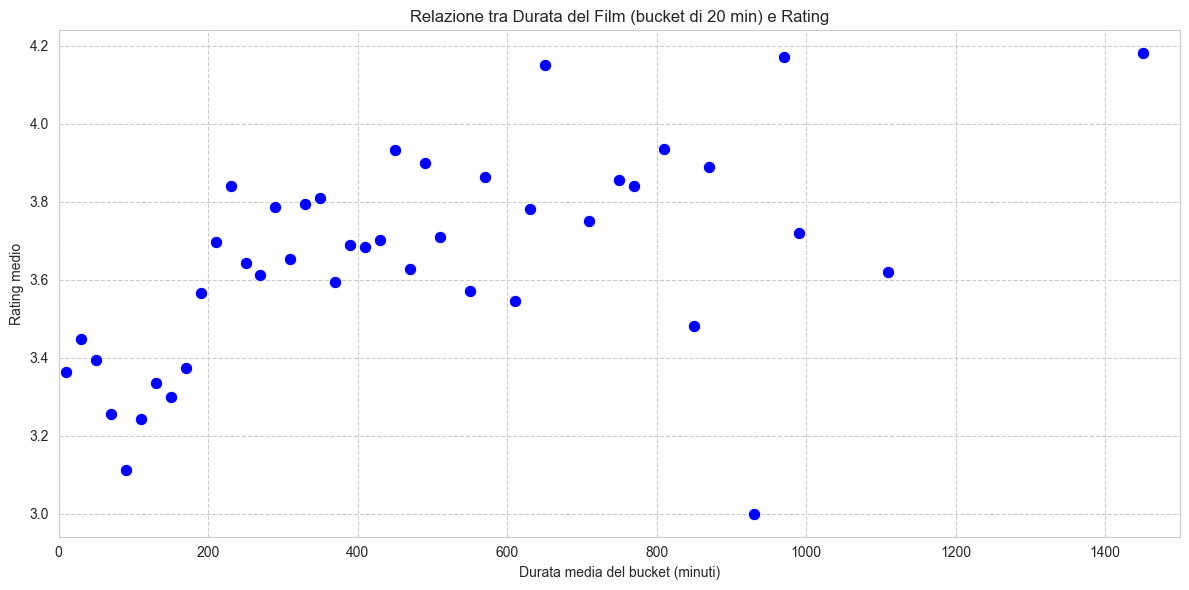

In [652]:
df_rating_movies = df_released_movies.copy()
df_rating_movies = df_rating_movies[(df_rating_movies['minute'] >= 0) & (df_rating_movies['minute'] <= 2000)] #elimino i film con durata negativa o eccessiva
bins = list(range(0, 1501, 20))  # da 0 a 1500 inclusi
df_rating_movies['minute_bin'] = pd.cut(df_rating_movies['minute'], bins=bins, right=False)

agg_rating = df_rating_movies.groupby('minute_bin',observed=False)['rating'].mean().reset_index() # raggruppo per bucket di 20 minuti e calcolo la media del rating

# Punto il centro del bucket per visualizzazione nel plot
agg_rating['minute_mid'] = agg_rating['minute_bin'].apply(lambda x: x.left + 10) # prendo il valore medio del bucket
plt.figure(figsize=(12, 6))
sns.scatterplot(x='minute_mid', y='rating', data=agg_rating, color='blue', s=80)
plt.xlim(0, 1500)
plt.title("Relazione tra Durata del Film (bucket di 20 min) e Rating")
plt.xlabel("Durata media del bucket (minuti)")
plt.ylabel("Rating medio")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Vediamo che la correlazione è presente in minima parte, possiamo dedurre quindi che le persone si affezionano ai personaggi su film che durano di più?


### Risultato analisi:

Uno dei fattori più evidenti che abbiamo analizzato è che il numero di film prodotti è aumentato notevolmente nel tempo. Questo porta a diversi effetti:

Diminuzione della qualità media: Con l'aumento del numero di film, è più probabile che vengano prodotti molti film di qualità inferiore, riducendo il rating medio complessivo.
Sovraccarico del pubblico: Con troppi film disponibili, gli spettatori possono diventare più esigenti e difficilmente daranno buone valutazioni.
Produzione industrializzata: La crescente commercializzazione e standardizzazione di molti film può portare a sceneggiature meno originali,con storie ripetute molte volte,abbassando la percezione della qualità.

Sicuramente il cambiamento del gusto del pubblico,infatti possiamo notare che ci sono generi che hanno un valore molto maggiore in alcune fasce annuali, come il Drama negli anni del dopoguerra e i generi Music negli anni più recenti.
Infine quasi sicuramente l'accessibilità alle recensioni è aumentata, causando quindi il voto del pubblico di essere maggiore con il tempo con l'avvento delle critiche online.


---


# Caccia all'Oscar: successo cinematografico tra merito, strategia e geografia

- Vi sono paesi che hanno prodotto più film di alto successo ? Se si, di conseguenza quei paesi avranno vinto più Oscar con film prodotti dal loro?
- Gli studios di Hollywood e la cinematografia francese, rispecchiano le aspettative e la nomea che si portano dietro in vincite di Oscars?
- È presente un genere di film che si discosta particolarmente rispetto agli altri per il numero di Oscar vinti? E' dunque la vincita di un oscar solo produzione o anche strategia?


Iniziamo l'analisi estraendo i paesi con film aventi un rating


In [653]:
df_movies

,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941586,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941587,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941588,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941589,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [654]:
successful_movies_countries= df_movies.merge(df_countries,left_on="id",right_on="id_film", how="left")  # unisco i due dataframe per avere le informazioni sui paesi
filtered_movies = successful_movies_countries[successful_movies_countries["rating"] > 3.5] # sopra la media
successful_movies_per_country = (
    filtered_movies.groupby('country')['id'].count().reset_index().rename(columns={'id': 'successful_movies_count'})
)
successful_movies_per_country = successful_movies_per_country.sort_values( # ordino per numero di film
    by='successful_movies_count', ascending=False
)

top_10 = successful_movies_per_country.head(10)

In [655]:
top_10

,country,successful_movies_count
161,USA,8395
54,France,2982
160,UK,2694
78,Japan,2198
57,Germany,1253
75,Italy,951
69,India,909
26,Canada,708
20,Brazil,699
144,South Korea,616


Notiamo quindi che gli Stati Uniti sono il paese con il maggior numero di film di successo, seguito da Francia e Regno Unito.
Possiamo aspettarci quindi che grafico degli oscar vinti per paese possa rispecchiare questo risultato, avendo l'America un numero maggiore di film di successo.
Calcoliamo quanti oscar sono stati vinti dai paesi produttori di film.


In [656]:
df_oscars["year_film"] = pd.to_numeric(df_oscars["year_film"], errors="coerce").astype("Int64") # converto in numerico
df_oscars["year_ceremony"] = pd.to_numeric(df_oscars["year_ceremony"], errors="coerce").astype("Int64") # converto in numerico

In [657]:
oscars_winners = df_oscars[df_oscars["winner"] == True] # prendo solo i vincitori
oscars_winners = oscars_winners.merge(df_movies, left_on="film", right_on="name", how="left") # unisco i due dataframe per avere le informazioni sui film
oscars_winners = oscars_winners.merge(df_countries, left_on="id", right_on="id_film", how="left")
oscar_per_country = oscars_winners.groupby("country").size().reset_index(name="oscar_count") # raggruppo per paese e conto gli oscar vinti

oscar_top_10 = top_10.merge(oscar_per_country, on="country", how="left").fillna(0) # unisco i due dataframe per avere le informazioni sui film
oscar_top_10 = oscar_top_10.sort_values(by="oscar_count", ascending=False)

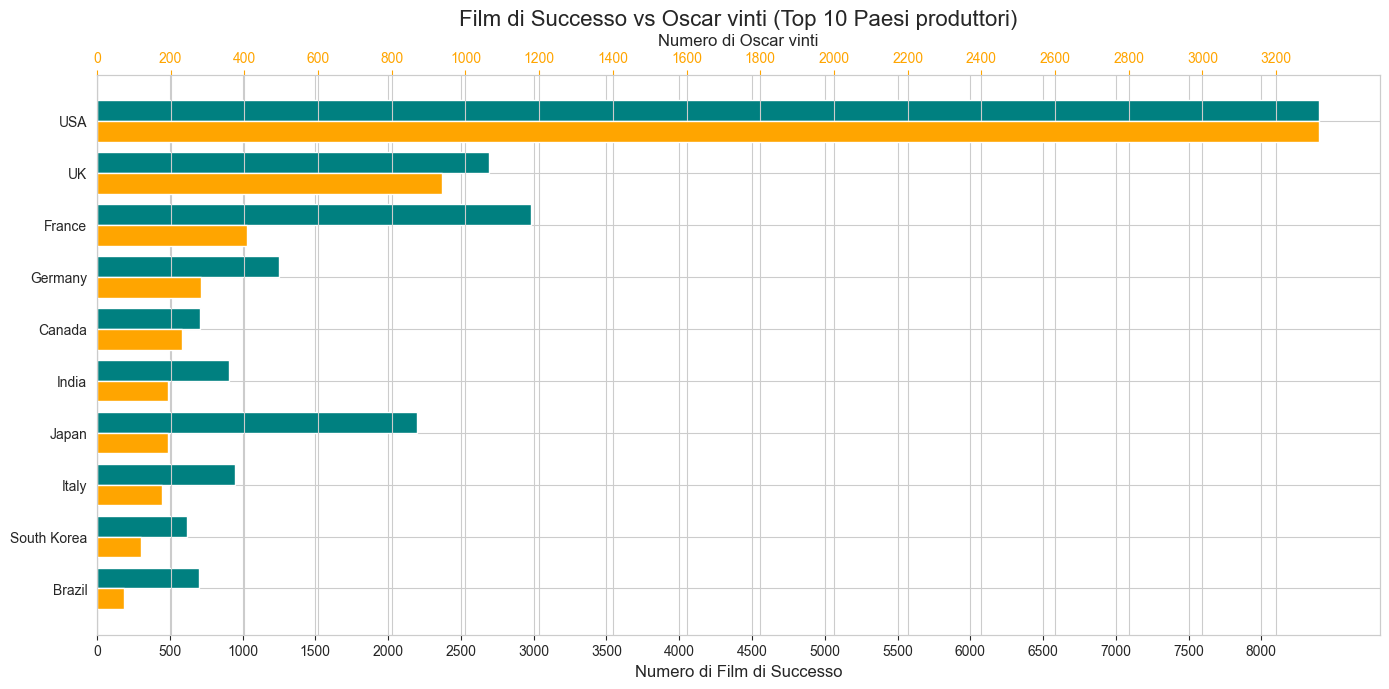

In [658]:
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_style("whitegrid")

countries = oscar_top_10['country']
x = np.arange(len(countries))
width = 0.4
#creiamo cosi 2 barre affiancate diverse 
ax1.barh(x - width/2, oscar_top_10['successful_movies_count'], height=width, label='Film di successo', color='teal')
ax1.set_xlabel("Numero di Film di Successo", fontsize=12)
ax1.set_yticks(x)
ax1.set_yticklabels(countries)
ax1.invert_yaxis() 
ax1.tick_params(axis='x')
ax1.set_xticks(np.arange(0, oscar_top_10['successful_movies_count'].max() + 1, 500))
ax2 = ax1.twiny()

ax2.barh(x + width/2, oscar_top_10['oscar_count'], height=width, label='Oscar vinti', color='orange')
ax2.set_xlabel("Numero di Oscar vinti", fontsize=12)
ax2.tick_params(axis='x', colors='orange')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_xticks(np.arange(0, max(oscar_top_10['oscar_count']), 200))
plt.title("Film di Successo vs Oscar vinti (Top 10 Paesi produttori)", fontsize=16)
fig.tight_layout()
plt.show()


In [659]:
#mappa con anche interazione interna facendo vedere il numero di oscar per paese
fig = px.choropleth(
    oscar_per_country.reset_index(), 
    locations='country', 
    locationmode='country names', 
    color='oscar_count',
    title="Paesi che hanno vinto più Oscar",
    color_continuous_scale='Viridis'
)
fig.show()

Vediamo chiaramente come l'America abbia un controllo sul numero di Oscar vinti, questo probabilmente dovuto alla supremazia di Hollywood come casa produttrice.
La situazione non cambia nelle prime 3 posizioni, mentre successivamente notiamo che i paesi con più film con oscar vinti variano rispetto ai paesi con film di maggior successo, identificando come questo non sia strettamente legato ai film di successo ma più alla quantità di film prodotti, quindi possiamo dedurre che con più film si hanno più possibilità di ottenere una nominazione qualsiasi agli Oscar.


## Hollywood e Cinematografia Francese


Poniamo il nostro confronto su un argomento più preciso:
La produzione di Hollywood contro il secondo paese in classifica per film con maggiore successo, ovvero la Francia.


Iniziamo ottenendo i film e le loro informazioni di Hollywood


In [660]:
hollywood_studios = ["warner", "paramount", "sony", "universal", "warner", "20thcenturyfox"] # metodo casereccio per tenere traccia di tutti gli studios hollywood
pattern = '|'.join(hollywood_studios)

In [661]:
#per ogni studio, prendiamo i film prodotti, ponendoli in lower case e confrontando con il pattern per vedere se appartangono ad Hollywood
df_hw_studios = df_studios[df_studios["studio"].apply(lambda x: x.lower().replace(" ", "")).str.contains(pattern, na=False, regex=True)].set_index("id_film")

e poniamo il nostro interesse all'interno della fascia di anni 1920 e 2020 dove abbiamo una presenza di dati consistente.


In [662]:
df_movies_filtered = df_released_movies.copy()
df_movies_filtered = df_movies_filtered[(df_movies_filtered['date'] >= 1920) & (df_movies_filtered['date'] <= 2020)] # prendiamo solo i film dal 1920 al 2020
df_hw_movies = df_movies_filtered[df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)] # prendiamo i film prodotti da Hollywood
df_not_hw_movies = df_movies_filtered[~df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)] # prendiamo i film non prodotti da Hollywood

In [663]:
df_hw_movies = df_hw_movies.copy()
df_not_hw_movies = df_not_hw_movies.copy()

df_hw_movies['year_bin'] = (df_hw_movies['date'] // 5) * 5 # bucket di 5 anni
df_not_hw_movies['year_bin'] = (df_not_hw_movies['date'] // 5) * 5 # bucket di 5 anni

df_rating_plot_hw = df_hw_movies.groupby('year_bin')['rating'].mean().reset_index() # raggruppo per bucket di 5 anni e calcolo la media del rating

Successivamente svolgiamo la stessa operazione con la cinematografia Francese.


In [664]:
df_french_movies = pd.merge(left=df_movies_filtered, right=df_countries, left_on='id', right_on='id_film', how="inner")
df_french_movies = df_french_movies[df_french_movies['country'] == 'France']
df_not_french_movies = df_movies_filtered[~df_movies_filtered.index.isin(df_french_movies.index)]

Ora possiamo mettere i rating a confronto per avere una idea su quali siano le loro tendenze.


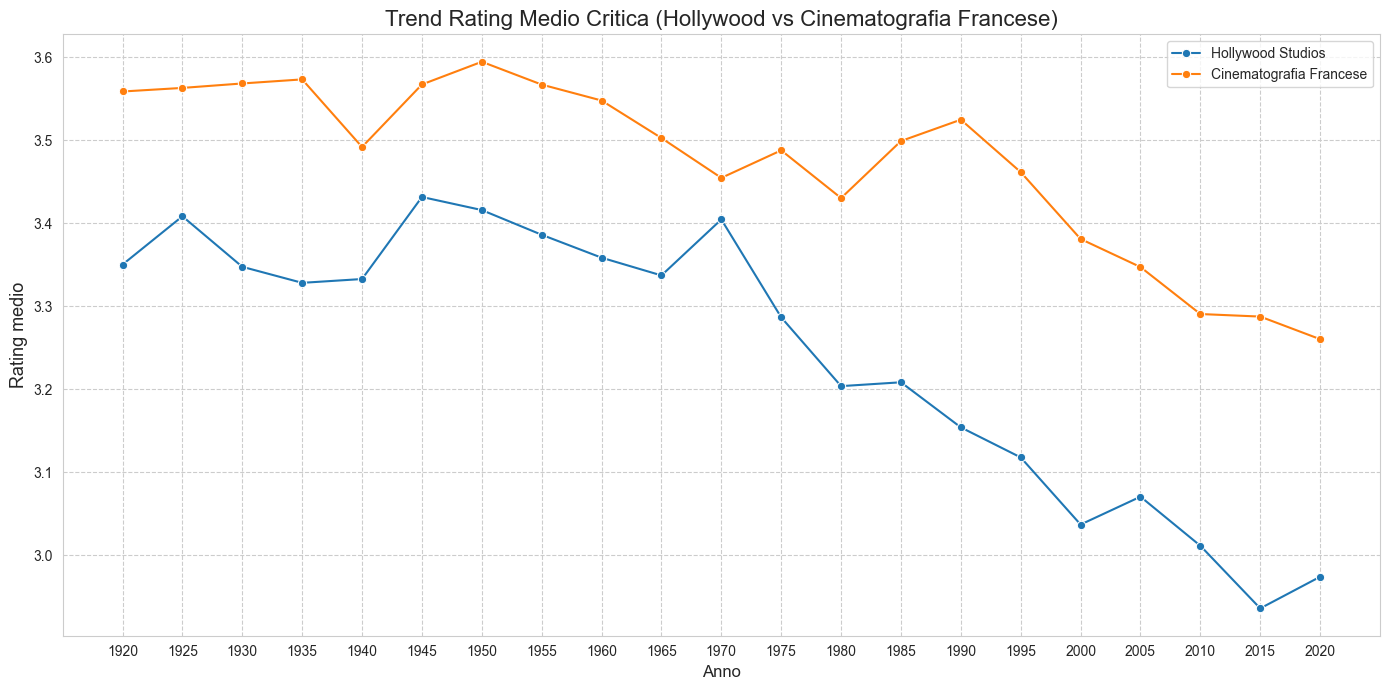

In [665]:
df_hw_movies['year_bin'] = (df_hw_movies['date'] // 5) * 5 # bucket di 5 anni
df_french_movies['year_bin'] = (df_french_movies['date'] // 5) * 5 # bucket di 5 anni

df_rating_plot_hw = df_hw_movies.groupby('year_bin')['rating'].mean().reset_index() # raggruppo per bucket di 5 anni e calcolo la media del rating di hollywood
df_rating_plot_french = df_french_movies.groupby('year_bin')['rating'].mean().reset_index() # raggruppo per bucket di 5 anni e calcolo la media del rating francesi

# plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_rating_plot_hw, x='year_bin', y='rating', label='Hollywood Studios', marker='o')
sns.lineplot(data=df_rating_plot_french, x='year_bin', y='rating', label='Cinematografia Francese', marker='o')
plt.title("Trend Rating Medio Critica (Hollywood vs Cinematografia Francese)", fontsize=16)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=13)
plt.gca().set_xticks(np.arange(1920, df_rating_plot_hw["year_bin"].max() + 5, 5))
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Dopo aver analizzato il rating medio di film dei rinomati Hollywood, della cinematografia francese e aver avuto una visione generale della situazione, poniamo il focus sugli oscar vinti da film francesi e da Hollywood


In [666]:
df_winning = df_oscars[df_oscars['winner'] == True] # prendo solo i vincitori
df_french_movies = pd.merge(left=df_movies_filtered, right=df_countries, left_on='id', right_on='id_film', how="inner") # unisco i due dataframe per avere le informazioni sui film
df_french_movies = df_french_movies[df_french_movies['country'] == 'France'] # prendo solo i film francesi
df_hw_movies = df_movies_filtered[df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)] # prendo solo i film prodotti da Hollywood

In [667]:
df_winning_hw = pd.merge(left=df_hw_movies, right=df_winning, left_on='name', right_on='film', how='inner')
df_winning_french = pd.merge(left=df_french_movies, right=df_winning, left_on='name', right_on='film', how='inner')
df_winning_hw = df_winning_hw.drop_duplicates(subset=['name_x']) # per sicurezza elimino i duplicati
df_winning_french = df_winning_french.drop_duplicates(subset=['name_x'])  # per sicurezza elimino i duplicati

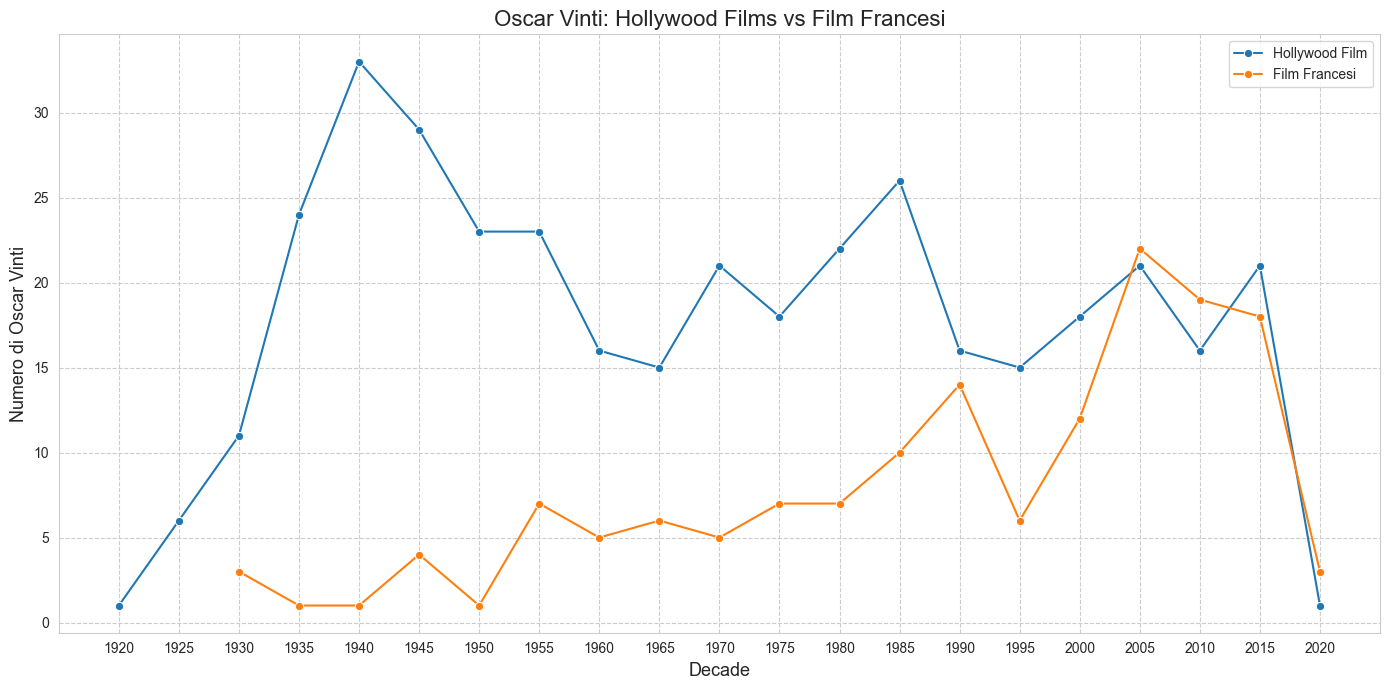

In [668]:
df_winning_hw['decade'] = (df_winning_hw['date'] // 5) * 5
df_winning_french['decade'] = (df_winning_french['date'] // 5) * 5

hw_decade_counts = df_winning_hw.groupby('decade').size().reset_index(name='count')
french_decade_counts = df_winning_french.groupby('decade').size().reset_index(name='count')

plt.figure(figsize=(14, 7))
sns.lineplot(data=hw_decade_counts, x='decade', y='count', marker='o', label='Hollywood Film')
sns.lineplot(data=french_decade_counts, x='decade', y='count', marker='o', label='Film Francesi')

plt.title("Oscar Vinti: Hollywood Films vs Film Francesi", fontsize=16)
plt.xlabel("Decade", fontsize=13)
plt.ylabel("Numero di Oscar Vinti", fontsize=13)
plt.gca().set_xticks(np.arange(1920, hw_decade_counts["decade"].max() + 5, 5)) # se no 'numpy.float64' object cannot be interpreted as an integer
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Nonostante il rating medio della critica sulla cinematografia francese sia costantemente negli anni più alto di quella di Hollywood, notiamo la supremazia negli anni da parte dei film Hollywoodiani.


Abbiamo osservato che i film prodotti in francia hanno generalmente vinto un numero di Oscar nettamente inferiore rispetto a quelli realizzati negli studi di Hollywood. Tuttavia, emerge un'interessante eccezione: nel decennio tra il 2000 e il 2010, i film francesi hanno registrato un'impennata nelle vittorie, avvicinandosi (e in alcuni casi superando) i successi hollywoodiani.

Negli anni successivi, però, Hollywood ha rapidamente ristabilito la sua supremazia, confermando la propria leadership storica nella produzione di film premiati, sostenuta da mezzi produttivi più imponenti, distribuzione globale e una forte influenza culturale sull'industria cinematografica mondiale.


## Il genere cinematografico di un film è correlato alla vincita di Oscars?


### Per avere una panoramica più ampia sullo storico dei film analizziamo i gusti come si sono evoluti negli anni (secondo la critica)


In [669]:
df_released_cl_data = df_released_movies.copy()
df_released_cl_data = df_released_cl_data.dropna(subset=["date"])[["id", "date", "rating", "name"]]
df_released_cl_data = df_released_cl_data.dropna(subset=["rating", "date"])
df_released_cl_data["date"] = df_released_cl_data["date"].astype(int) # converto in int
df_released_cl_data = df_released_cl_data[(1920<df_released_cl_data["date"])&(df_released_cl_data["date"]<2020)] # elimino i film con data non valida

{'whiskers': [<matplotlib.lines.Line2D at 0x356562780>,
 'caps': [<matplotlib.lines.Line2D at 0x35ebd2030>,
 'boxes': [<matplotlib.lines.Line2D at 0x3565607a0>],
 'medians': [<matplotlib.lines.Line2D at 0x356562660>],
 'fliers': [<matplotlib.lines.Line2D at 0x3565621b0>],
 'means': []}

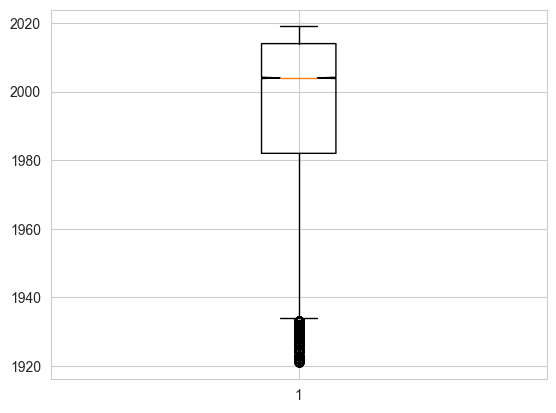

In [670]:
plt.boxplot(df_released_cl_data["date"], df_released_cl_data.groupby("date")["rating"].count().tolist())

In [671]:
merged_themes = df_themes.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_themes["date_bin"] = (merged_themes["date"] // 10) * 10 #per avere le date con strutture simili

df_date_theme = merged_themes[["date_bin", "theme"]].groupby("date_bin").value_counts().to_frame() # raggruppo per decade e tema

idx = df_date_theme.groupby(level=0)["count"].idxmax() # prendo l'indice del valore massimo per ogni bin
df_date_hot_theme = df_date_theme.loc[idx].reset_index() # resetto l'indice


In [672]:
merged_genre = df_genres.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_genre["date_bin"] = (merged_genre["date"] // 10) * 10 # per avere le date con strutture simili

df_date_genre = merged_genre[["date_bin", "genre"]].groupby("date_bin").value_counts().to_frame() # raggruppo per decade e genere e conto il numero di film

idx = df_date_genre.groupby(level=0)["count"].idxmax() # prendo l'indice del valore massimo per ogni bin
df_date_hot_genre = df_date_genre.loc[idx].reset_index() # resetto l'indice

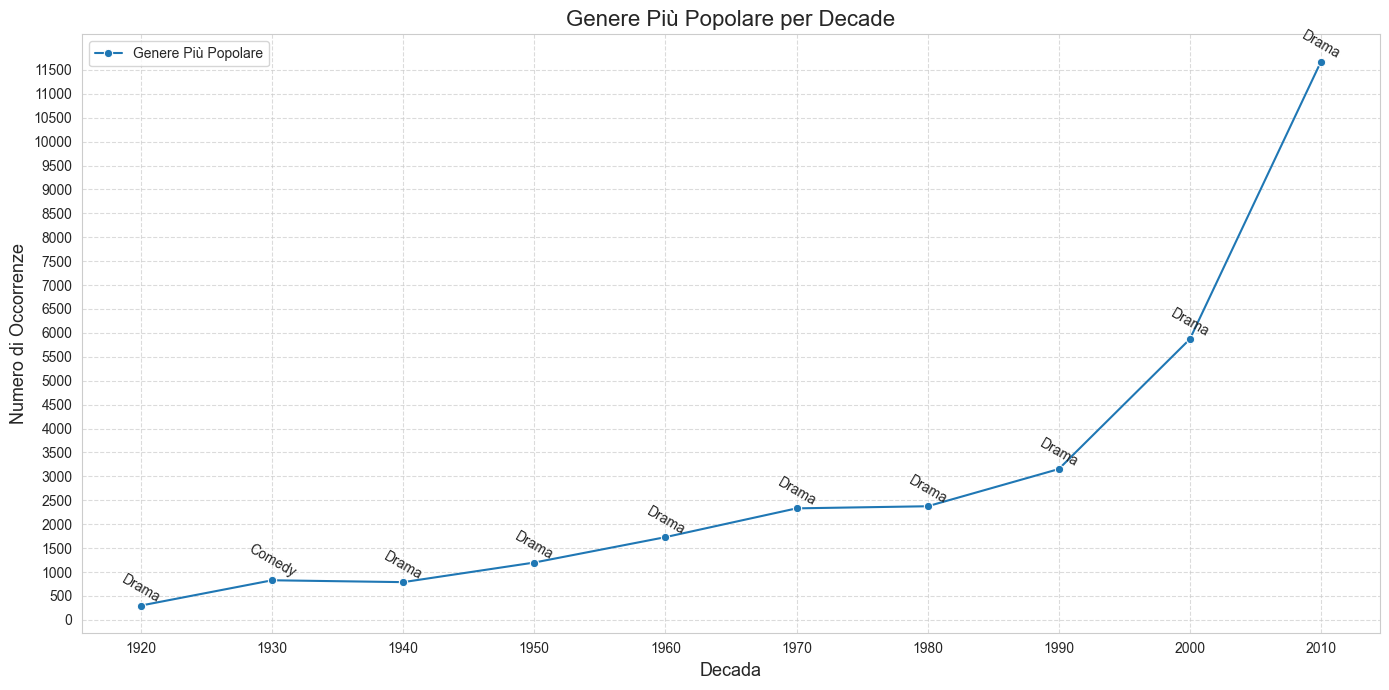

In [673]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_date_hot_genre, x='date_bin', y='count', marker='o', label='Genere Più Popolare')

for i, txt in enumerate(df_date_hot_genre["genre"]):
    plt.text(df_date_hot_genre["date_bin"].iloc[i], df_date_hot_genre["count"].iloc[i], txt,
             fontsize=10, ha="center", va="bottom", rotation=-30)

plt.title("Genere Più Popolare per Decade", fontsize=16)
plt.xlabel("Decada", fontsize=13)
plt.ylabel("Numero di Occorrenze", fontsize=13)
plt.gca().set_yticks(np.arange(0, df_date_hot_genre["count"].max() + 100, 500))
plt.gca().set_xticks(np.arange(df_date_hot_genre["date_bin"].min(), df_date_hot_genre["date_bin"].max()+10, 10))

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

Vediamo chiaramente come il genere drammatico sia prevalente al di sopra di ogni altro, nell'insieme generale degli anni.
Sicuramente la causa principale è la vastità di film di questo tipo.

Raggruppiamo ora per genere, che rispecchia i temi di cui trattano i film.


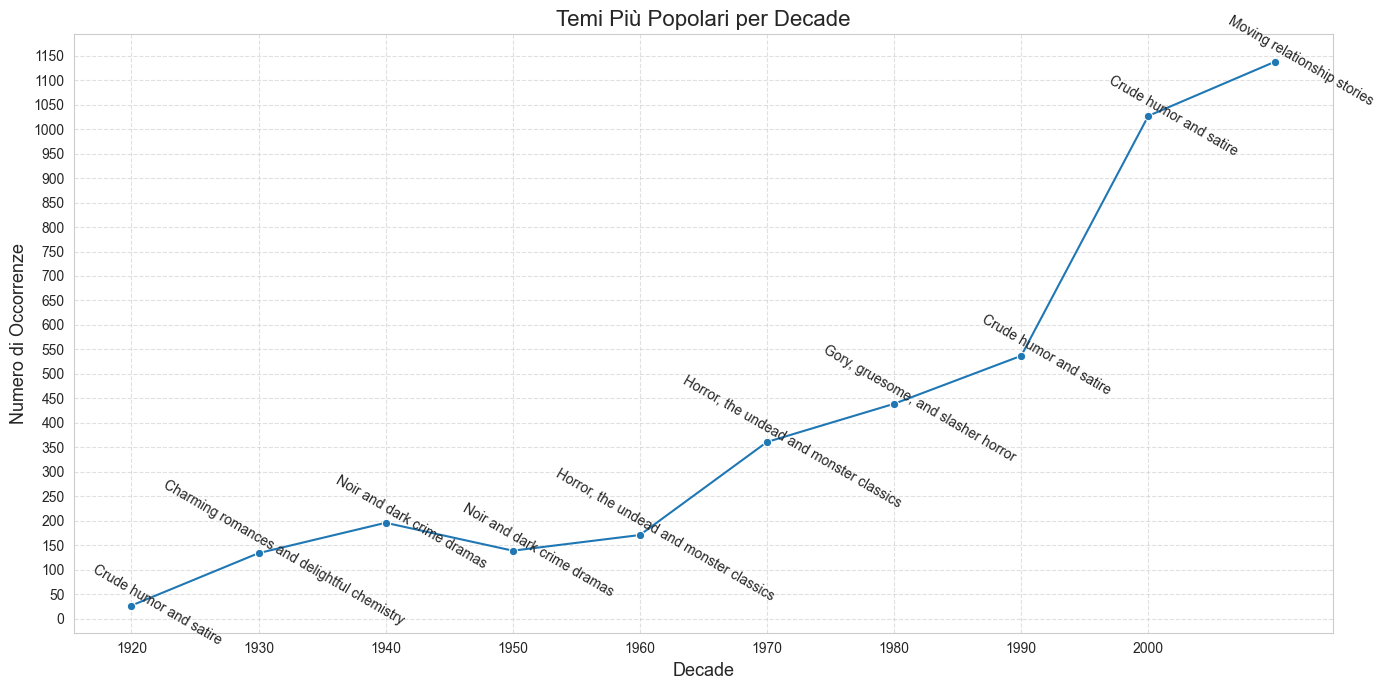

In [674]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_date_hot_theme, x='date_bin', y='count', marker='o')
for i, txt in enumerate(df_date_hot_theme["theme"]):
    plt.text(
        df_date_hot_theme["date_bin"].iloc[i] + 2,
        df_date_hot_theme["count"].iloc[i] + 0.5,
        txt,
        fontsize=10,
        ha="center",
        va="center",  # Eliminates built-in text padding
        rotation=-30
    )

plt.title("Temi Più Popolari per Decade", fontsize=16)
plt.xlabel("Decade", fontsize=13)
plt.ylabel("Numero di Occorrenze", fontsize=13)
plt.gca().set_yticks(np.arange(0, df_date_hot_theme["count"].max() + 50, 50))
plt.gca().set_xticks(np.arange(df_date_hot_theme["date_bin"].min(), df_date_hot_theme["date_bin"].max(), 10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [675]:
genre_rating = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).agg(['mean', 'count'])["rating"].reset_index() # calcoliamo la media del rating per ogni decennio e genere
rating_per_year = merged_genre[["date_bin", "rating"]].groupby(["date_bin"]).count().reset_index().set_index("date_bin") # contiamo il numero di film per anno

In [676]:
genre_rating["mean_count"] = genre_rating["mean"] * genre_rating["count"] # media pesata

In [677]:
genre_rating["w_avg"] = genre_rating.apply(lambda x: x["mean_count"]/rating_per_year["rating"][x["date_bin"]], axis=1)
#per ogni riga, viene creata un valore della nuova colonna w_avg, che è il rating medio pesato per il numero di film prodotti in quell'anno

In [678]:
df_highest_genre = genre_rating.loc[genre_rating.groupby("date_bin")["w_avg"].idxmax()].reset_index(drop=True) # prendo il valore massimo per ogni decade

In [679]:
genre_rating_dropped = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).mean().dropna(subset=["rating"]) # raggruppo per decade e calcolo la media del rating

In [680]:
idx = genre_rating_dropped.groupby(level=0)["rating"].idxmax() # prendo l'indice del valore massimo per ogni bin
df_date_best_genre = genre_rating_dropped.loc[idx].reset_index() # resetto l'indice

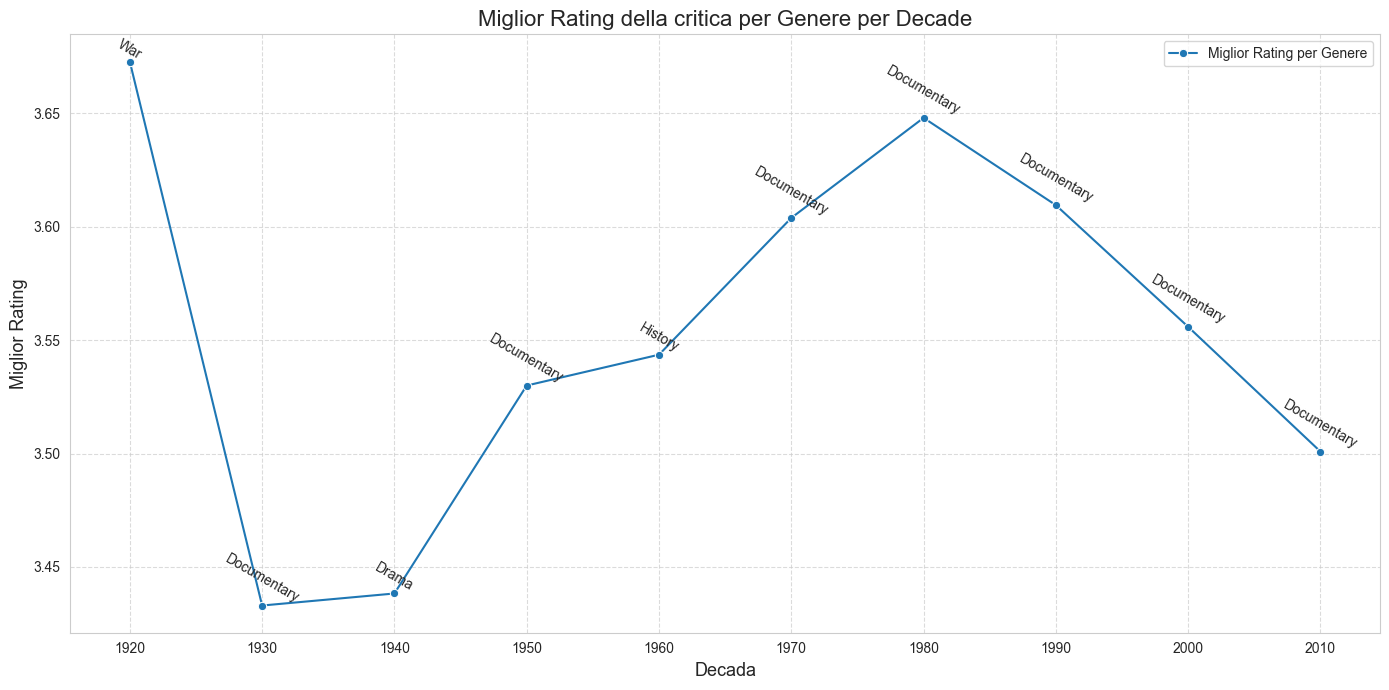

In [681]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_date_best_genre, x='date_bin', y='rating', marker='o', label='Miglior Rating per Genere')

for i, txt in enumerate(df_date_best_genre["genre"]):
    plt.text(df_date_best_genre["date_bin"].iloc[i], df_date_best_genre["rating"].iloc[i], txt,
             fontsize=10, ha="center", va="bottom", rotation=-30)

plt.title("Miglior Rating della critica per Genere per Decade", fontsize=16)
plt.xlabel("Decada", fontsize=13)
plt.ylabel("Miglior Rating", fontsize=13)
plt.gca().set_xticks(np.arange(df_date_best_genre["date_bin"].min(), df_date_best_genre["date_bin"].max()+10, 10)) # se no 'numpy.float64' object cannot be interpreted as an integer


plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

Con queste informazioni possiamo costruire un grafico per evidenziare quali di questi generi ha più premi.


Analiziamo i generi premiati di più nella storia cinematografica per poter vedere se esso è un fattore discriminatorio nella vittoria dei premi.


In [682]:
df_oscars['film'] = df_oscars['film'].fillna('') # riempiamo i NaN con stringhe vuote
df_released_movies['name'] = df_released_movies['name'].fillna('') # riempiamo i NaN con stringhe vuote

In [683]:
def normalize_title(title):          # semplice funzione per normalizzare i titoli
    return title.lower().strip()

df_oscars['film_norm'] = df_oscars['film'].apply(normalize_title)
df_released_movies['name_norm'] = df_released_movies['name'].apply(normalize_title)

In [684]:
oscars_winners = df_oscars[df_oscars["winner"] == True] 
oscars_winners = oscars_winners.merge(df_released_movies, left_on="film_norm", right_on="name_norm", how="inner")
oscars_genres = oscars_winners.merge(df_genres, left_on="id", right_on="id_film", how="left")

oscars_per_genre = ( # raggruppo per genere e calcolo il numero di oscar vinti
    oscars_genres.groupby("genre")
    .size()
    .reset_index(name="oscar_wins")
    .sort_values(by="oscar_wins", ascending=False)
)

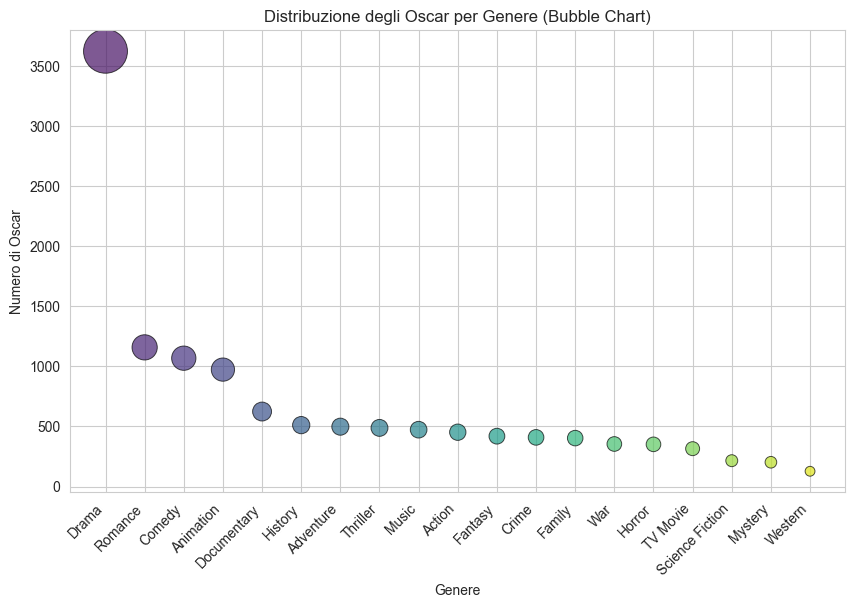

In [685]:
plt.figure(figsize=(10, 6))
scatter=sns.scatterplot(
    x=range(len(oscars_per_genre)), 
    y=oscars_per_genre["oscar_wins"], 
    size=oscars_per_genre["oscar_wins"], 
    sizes=(50, 1000),  # dimensione delle bolle
    hue=oscars_per_genre["genre"], 
    palette="viridis", 
    edgecolor="black", 
    alpha=0.7,
    legend=False
)
plt.xticks(range(len(oscars_per_genre)), oscars_per_genre["genre"], rotation=45, ha="right")
plt.xlabel("Genere")
plt.ylabel("Numero di Oscar")
plt.title("Distribuzione degli Oscar per Genere (Bubble Chart)")
plt.show()

Non è solo la qualità o la quantità dei film a influenzare il successo agli Oscar.
È anche una questione di scelta strategica dei generi.
In particolare, il Drama è nettamente favorito.
Analiziamo quindi la percentuale di film drammatici prodotti nei paesi con più Oscar.


Il drama non solo è il genere più aprezzato nella storia della cinematografia ma è anche il genere con più oscar vinti di sempre


In [686]:
drama_genres = df_genres[df_genres['genre'] == 'Drama'] #  prendo solo i film di genere Drama
drama_films = pd.merge(left=drama_genres, right=df_released_movies, left_on='id_film', right_on='id', how='inner') # unisco i due dataframe per avere le informazioni sui film

In [687]:
drama_with_country = pd.merge(drama_films, df_countries, left_on='id', right_on='id_film')# unisco i due dataframe per avere le informazioni sui paesi

In [688]:
drama_with_top_10 = drama_with_country[drama_with_country['country'].isin(top_10['country'])] # prendiamo i film drammatici dei paesi top 10
drama_count_top10 = drama_with_top_10['country'].value_counts() # contiamo i film drammatici per paese

In [689]:
total_films_per_country = df_countries['country'].value_counts() # prendo il numero totale di film per ogni paese
total_films_top10 = total_films_per_country.loc[top_10['country']] # prendo i film totali per i paesi top 10

In [690]:
drama_percentage_top10 = (drama_count_top10 / total_films_top10) * 100
drama_percentage_top10

country
Brazil         24.099465
Canada         26.316474
France         30.532531
Germany        33.420448
India          48.381191
Italy          32.115395
Japan          25.209129
South Korea    37.722096
UK             26.389989
USA            25.235975
Name: count, dtype: float64

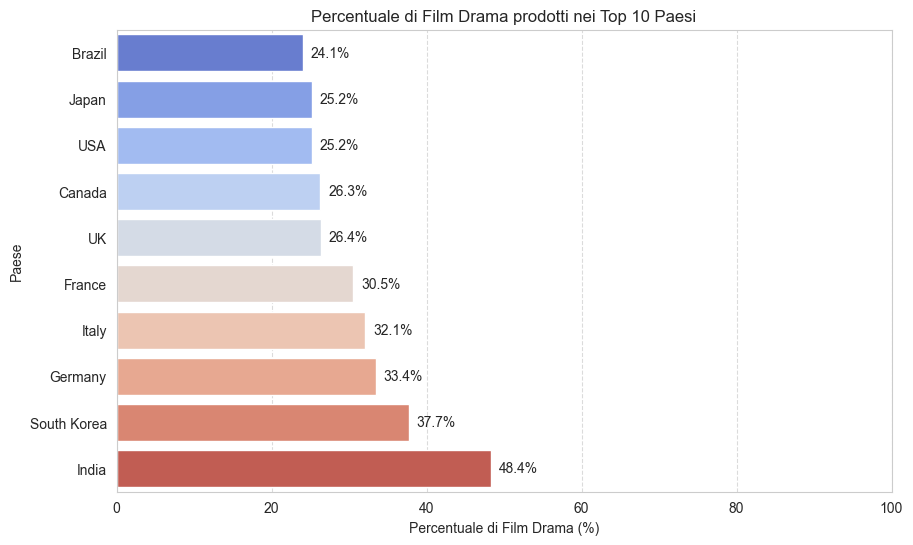

In [691]:
drama_percentage_top10 = drama_percentage_top10.sort_values(ascending=True)  # ascendente per barh
plt.figure(figsize=(10, 6))
sns.barplot(
    x=drama_percentage_top10, 
    y=drama_percentage_top10.index, 
    hue=drama_percentage_top10.index, #ogni barra è colorata in modo diverso
    palette="coolwarm",
    legend=False  
)

for index, value in enumerate(drama_percentage_top10):
    plt.text(value + 1, index, f"{value:.1f}%", va='center')

plt.xlabel('Percentuale di Film Drama (%)')
plt.ylabel('Paese')
plt.title('Percentuale di Film Drama prodotti nei Top 10 Paesi')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Nonostante il drama sia il genere con più oscar vinti, non è il genere più prodotto!
Inoltre gli USA, paese con più oscar vinti, notiamo che in percentuale non produce più film drama rispetto ad altri paese con minor numero di oscar vinti


### Risultato della analisi:

Possiamo affermare che l'America è il paese che ha prodotto film di maggiore successo all'interno nella storia, vincendo anche la maggior parte degli Oscar nei film prodotti nel paese, specificatamente grazie ai film prodotti ad Hollywood.

Abbiamo poi condotto un confronto tra due storici colossi della cinematografia, quella francese e la Hollywoodiana, traendo alcune conclusioni:

- Hollywood storicamente ha sempre vinto più oscars
- La cinematografia francese ha avuto un apprezzamento dalla critica negli anni sempre maggiore ai film prodotti ad Hollywood

La conclusione di questo ramo dell'analisi è finita con la curiosità di scoprire come i generi influenzassero la vittoria di un Oscar. Il drama domina le classifiche di Oscar vinti.
